In [15]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('working from:', ROOT.name)

working from: project


In [16]:
import yfinance as yf
import pandas as pd

data = yf.download("SPY", start="2015-01-01", end="2026-08-01", progress=False)

# Flatten the MultiIndex columns down to simple names
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(data.shape)
print(data.head())

(2911, 5)
Price            Close        High         Low        Open     Volume
Date                                                                 
2015-01-02  169.687836  170.885565  168.655319  170.472558  121465900
2015-01-05  166.623337  168.812266  166.317716  168.647066  169632600
2015-01-06  165.053925  167.449357  164.260947  166.928965  209151400
2015-01-07  167.110703  167.449371  165.929510  166.375551  125346700
2015-01-08  170.076080  170.290852  168.498405  168.514916  147217800


In [17]:
data.to_csv(ROOT / "data" / "raw" / "spy_raw.csv")
print(f"Saved {len(data)} rows to data/raw/spy_raw.csv")

Saved 2911 rows to data/raw/spy_raw.csv


Data Source & Validation
Source: Yahoo Finance, via the yfinance Python library (API pull, no manual download or key required)
Ticker: SPY
Date range: 2015-01-01 to 2026-08-01
Rows: 2,911
Validation: no missing values found (see check below); date range and row count consistent with expected trading days over this period

In [18]:
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [19]:
from dotenv import load_dotenv
load_dotenv()

import sys
sys.path.append(str(ROOT / "src"))
from utils import save_raw_data, load_raw_data

# Save using the new env-driven function
save_raw_data(data, "spy_raw.csv")

# Reload to confirm it round-trips correctly
reloaded = load_raw_data("spy_raw.csv")
print(reloaded.head())

Saved 2911 rows to data/raw/spy_raw.csv
Loaded 2911 rows from data/raw/spy_raw.csv
                 Close        High         Low        Open     Volume
Date                                                                 
2015-01-02  169.687836  170.885565  168.655319  170.472558  121465900
2015-01-05  166.623337  168.812266  166.317716  168.647066  169632600
2015-01-06  165.053925  167.449357  164.260947  166.928965  209151400
2015-01-07  167.110703  167.449371  165.929510  166.375551  125346700
2015-01-08  170.076080  170.290852  168.498405  168.514916  147217800


In [20]:
sys.path.append(str(ROOT / "src"))
from cleaning import preprocess_pipeline

raw = load_raw_data("spy_raw.csv")
processed = preprocess_pipeline(raw)

processed.to_csv(ROOT / "data" / "processed" / "spy_processed.csv")
print(f"Saved {len(processed)} processed rows")
print(processed.head())

Loaded 2911 rows from data/raw/spy_raw.csv
Removed 0 duplicate rows
Filled 0 missing values via forward-fill
Saved 2911 processed rows
                 Close        High         Low        Open     Volume
Date                                                                 
2015-01-02  169.687836  170.885565  168.655319  170.472558  121465900
2015-01-05  166.623337  168.812266  166.317716  168.647066  169632600
2015-01-06  165.053925  167.449357  164.260947  166.928965  209151400
2015-01-07  167.110703  167.449371  165.929510  166.375551  125346700
2015-01-08  170.076080  170.290852  168.498405  168.514916  147217800


Preprocessing assumptions: Missing values are forward-filled, assuming the last known price holds until new data arrives (standard for financial time series, avoids fabricating values). Duplicate dates are dropped, keeping the first occurrence. Data is sorted chronologically to support time-series modeling in later stages.

In [21]:
sys.path.append(str(ROOT / "src"))
from outliers import detect_outliers_zscore, remove_outliers

flagged = detect_outliers_zscore(processed)
print(flagged[flagged["is_outlier"]][["Close"]])

Flagged 39 outliers out of 2911 rows (1.34%)
                 Close
Date                  
2015-08-24  157.992966
2015-08-26  162.128311
2016-06-24  173.122498
2018-02-05  231.705231
2018-02-08  226.174454
2018-12-26  220.227676
2020-02-24  293.892059
2020-02-27  271.186188
2020-03-02  281.741516
2020-03-04  285.178009
2020-03-05  275.698090
2020-03-09  249.965958
2020-03-10  262.900421
2020-03-11  250.084473
2020-03-12  226.157059
2020-03-13  245.490417
2020-03-16  218.627914
2020-03-17  230.432068
2020-03-18  218.764664
2020-03-20  209.781998
2020-03-24  222.939194
2020-03-26  239.488922
2020-04-01  225.689835
2020-04-06  242.844696
2020-06-11  275.623047
2020-09-03  318.074585
2020-10-28  302.029968
2022-04-29  388.862946
2022-05-05  390.571350
2022-05-18  369.854004
2022-06-13  353.940796
2022-06-16  346.059723
2022-08-26  384.201172
2022-09-13  372.627136
2022-11-10  375.671112
2025-04-03  529.253723
2025-04-04  498.269684
2025-04-09  541.008423
2025-04-10  517.301880


In [22]:
sys.path.append(str(ROOT / "src"))
from eda import eda_summary
import matplotlib.pyplot as plt

summary_stats = eda_summary(processed)

mean_price: 354.620122
median_price: 317.637268
std_price: 158.715464
min_price: 154.161652
max_price: 757.618225
missing_values: 0
mean_daily_return: 0.000571
std_daily_return: 0.011097
skewness_returns: -0.307511


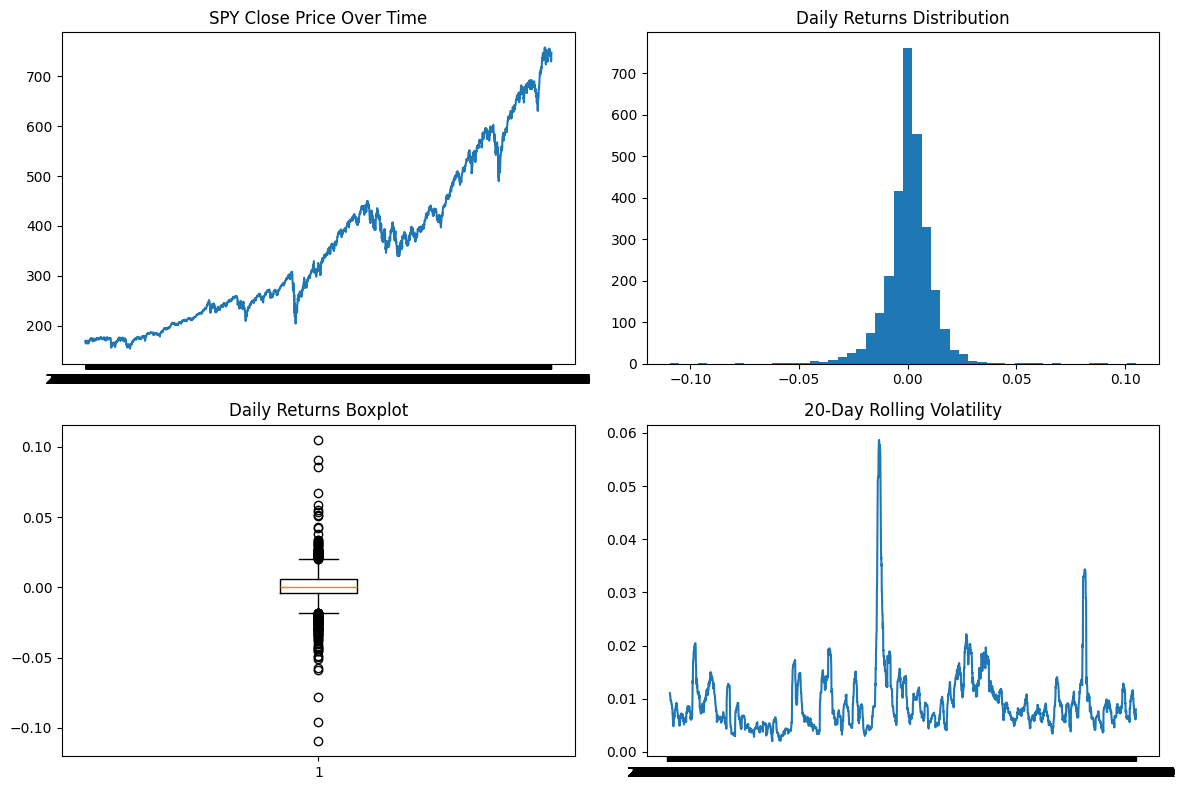

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Time series
axes[0, 0].plot(processed.index, processed["Close"])
axes[0, 0].set_title("SPY Close Price Over Time")

# Returns histogram
returns = processed["Close"].pct_change().dropna()
axes[0, 1].hist(returns, bins=50)
axes[0, 1].set_title("Daily Returns Distribution")

# Boxplot - shows outliers visually
axes[1, 0].boxplot(returns)
axes[1, 0].set_title("Daily Returns Boxplot")

# Rolling volatility (bonus insight, cheap to add)
rolling_vol = returns.rolling(20).std()
axes[1, 1].plot(processed.index[1:], rolling_vol)
axes[1, 1].set_title("20-Day Rolling Volatility")

plt.tight_layout()
plt.savefig(ROOT / "reports" / "images" / "eda_summary.png")
plt.show()

In [24]:
sys.path.append(str(ROOT / "src"))
from features import build_features

featured = build_features(processed)
featured.to_csv(ROOT / "data" / "processed" / "spy_features.csv")
print(f"Built {len(featured)} rows with {featured.shape[1]} columns")
print(featured.columns.tolist())
print(featured.head())

Built 2891 rows with 12 columns
['Close', 'High', 'Low', 'Open', 'Volume', 'ma_5', 'ma_10', 'ma_20', 'momentum', 'volatility', 'rsi', 'target']
                 Close        High         Low        Open     Volume  \
Date                                                                    
2015-02-02  166.788498  166.879360  163.434888  165.243858  163107000   
2015-02-03  169.200531  169.208799  167.308966  167.680670  124212900   
2015-02-04  168.556183  169.646526  168.101873  168.440542  134306700   
2015-02-05  170.257828  170.406517  169.142718  169.217056   97953200   
2015-02-06  169.787018  171.182982  169.266625  170.621287  125672000   

                  ma_5       ma_10       ma_20  momentum  volatility  \
Date                                                                   
2015-02-02  166.233447  167.507172  167.190816  0.239471    0.011050   
2015-02-03  166.580380  167.736806  167.319675  2.296341    0.010766   
2015-02-04  167.227960  167.817757  167.494788  0.809509

In [25]:
sys.path.append(str(ROOT / "src"))
from model import run_walk_forward, FEATURE_COLS

logistic_results = run_walk_forward(featured, model_type="logistic")
rf_results = run_walk_forward(featured, model_type="random_forest")

print("Logistic Regression - walk-forward results:")
print(logistic_results)
print(f"\nMean accuracy: {logistic_results['accuracy'].mean():.4f}")

print("\nRandom Forest - walk-forward results:")
print(rf_results)
print(f"\nMean accuracy: {rf_results['accuracy'].mean():.4f}")

Logistic Regression - walk-forward results:
   accuracy  precision    recall  n_test  fold
0  0.528067   0.552279  0.774436     481     1
1  0.538462   0.597360  0.644128     481     2
2  0.525988   0.525988  1.000000     481     3
3  0.544699   0.544699  1.000000     481     4
4  0.563410   0.563410  1.000000     481     5

Mean accuracy: 0.5401

Random Forest - walk-forward results:
   accuracy  precision    recall  n_test  fold
0  0.505198   0.600000  0.315789     481     1
1  0.436590   0.589286  0.117438     481     2
2  0.480249   1.000000  0.011858     481     3
3  0.498960   0.551724  0.427481     481     4
4  0.449064   0.636364  0.051661     481     5

Mean accuracy: 0.4740


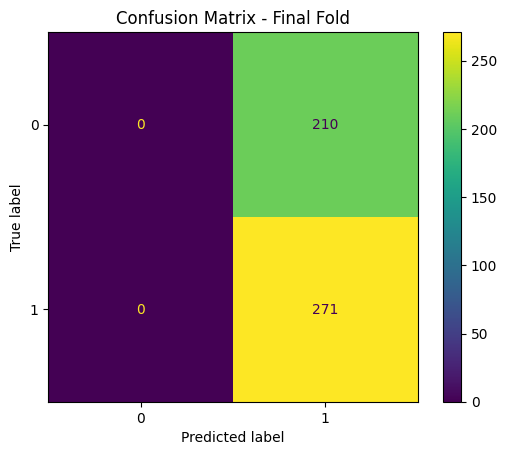

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from model import build_pipeline, walk_forward_split

# Refit on the last fold for a concrete diagnostic view
last_train, last_test = walk_forward_split(featured, n_splits=5)[-1]
pipeline = build_pipeline("logistic")
pipeline.fit(last_train[FEATURE_COLS], last_train["target"])
preds = pipeline.predict(last_test[FEATURE_COLS])

ConfusionMatrixDisplay.from_predictions(last_test["target"], preds)
plt.title("Confusion Matrix - Final Fold")
plt.savefig(ROOT / "reports" / "images" / "confusion_matrix.png")
plt.show()

In [27]:
sys.path.append(str(ROOT / "src"))
from evaluations import bootstrap_accuracy_ci, majority_baseline_ci, compare_scenarios

# Bootstrap CI on the final fold's actual predictions (from Stage 10's confusion matrix)
model_mean, model_lower, model_upper = bootstrap_accuracy_ci(last_test["target"], preds)
print(f"Model accuracy: {model_mean:.4f} [{model_lower:.4f}, {model_upper:.4f}]")

# Same CI, computed for the naive majority-class baseline
majority_class = last_train["target"].mode()[0]
base_mean, base_lower, base_upper = majority_baseline_ci(last_test["target"], majority_class)
print(f"Baseline accuracy: {base_mean:.4f} [{base_lower:.4f}, {base_upper:.4f}]")

Model accuracy: 0.5626 [0.5197, 0.6071]
Baseline accuracy: 0.5626 [0.5197, 0.6071]


In [28]:
# import matplotlib.pyplot as plt

# labels = ["Model", "Majority Baseline"]
# means = [model_mean, base_mean]
# lowers = [model_mean - model_lower, base_mean - base_lower]
# uppers = [model_upper - model_mean, base_upper - base_mean]

# fig, ax = plt.subplots(figsize=(6, 5))
# ax.errorbar(labels, means, yerr=[lowers, uppers], fmt='o', capsize=8, markersize=10)
# ax.set_ylabel("Accuracy")
# ax.set_title("Model vs. Majority Baseline - 95% Bootstrap CI")
# ax.set_ylim(0.3, 0.7)
# ax.grid(alpha=0.3)
# plt.tight_layout()
# plt.savefig(ROOT / "reports" / "images" / "bootstrap_ci_comparison.png")
# plt.show()

In [29]:
from model import build_pipeline, FEATURE_COLS

def quick_accuracy(df, cols, target_col):
    train, test = walk_forward_split(df, n_splits=5)[-1]
    pipe = build_pipeline("logistic")
    pipe.fit(train[cols], train[target_col])
    preds = pipe.predict(test[cols])
    return (preds == test[target_col].values).mean()

scenarios = {
    "full_feature_set": FEATURE_COLS,
    "momentum_only": ["momentum", "volatility"],
}

scenario_results = compare_scenarios(featured, quick_accuracy, scenarios)
print(scenario_results)

{'full_feature_set': np.float64(0.5634095634095634), 'momentum_only': np.float64(0.5634095634095634)}


In [30]:
print("Stakeholder report generated: reports/stakeholder_report.md")
print("Includes: confusion matrix, bootstrap CI comparison, scenario sensitivity, assumptions & risks")

Stakeholder report generated: reports/stakeholder_report.md
Includes: confusion matrix, bootstrap CI comparison, scenario sensitivity, assumptions & risks


In [31]:
from model import save_model, load_model

save_model(pipeline, str(ROOT / "model" / "model.pkl"))

Model saved to /Users/a1/Desktop/bootcamp_kashish_dhoka/project/model/model.pkl


In [32]:
# Verify refactor didn't change anything
from model import load_model, predict_direction

loaded_pipeline = load_model(str(ROOT / "model" / "model.pkl"))
sample_row = last_test.iloc[0]
refactored_pred = predict_direction(loaded_pipeline, sample_row[FEATURE_COLS].to_dict())
original_pred = preds[0]

print(f"Original prediction: {original_pred}, Refactored prediction: {refactored_pred}")
assert original_pred == refactored_pred, "Refactor changed behavior!"
print("Refactor verified - matches original.")

Original prediction: 1, Refactored prediction: 1
Refactor verified - matches original.


In [33]:
import requests

sample_features = last_test.iloc[0][FEATURE_COLS].to_dict()
response = requests.post("http://127.0.0.1:5000/predict", json=sample_features)
print(response.status_code)
print(response.json())

200
{'meaning': '1=up, 0=down', 'prediction': 1}
